# Student Stress Prediction: Machine Learning Pipeline

## Team Members
- [Member 1 Name]
- [Member 2 Name]
- [Member 3 Name]
- [Member 4 Name]

## Project Description
This project predicts student stress levels encoded in **3 distinct binned categories** based on information about various aspects of student life including relationships, finances, student habits, and substance use.

### Problem Statement (Classification)
Predict student stress levels categorized into three distinct classes:
- **Low Stress**: Score range 1-3
- **Average Stress**: Score range 4-6  
- **High Stress**: Score range 7-10

### Web Application
- **Frontend**: React-based interface for student data input and stress prediction visualization
- **Backend**: FastAPI server with REST endpoints for model inference
- **Live Demo**: Available at [ngrok URL]

### Machine Learning Models
The pipeline implements and compares three classification models:
1. **Logistic Regression**: Baseline linear model for multi-class classification
2. **Neural Network**: Deep learning approach with multiple hidden layers
3. **Gradient Boosting**: Ensemble method using decision trees

All models are trained to classify students into one of the three stress categories based on their survey responses.

### Import Libraries
Import all necessary Python libraries for data processing, machine learning, and visualization.

In [159]:
# Import standard libraries
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

### Configure Project Paths
Set up the project directory structure and add paths to Python's module search path for importing backend modules.

In [160]:
project_root = Path.cwd()
if not (project_root / "backend").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

backend_root = project_root / "backend"
for p in (project_root, backend_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
        
print("✓ Paths configured")

✓ Paths configured


### Input Features
The model uses diverse student lifestyle and demographic data:
- **Relationships**: Relationship status, social engagement, friends count
- **Finances**: Rent expenses, financial pressure indicators
- **Student Habits**: Study hours, work hours, commute time, learning styles, attendance mode
- **Substance Use**: Drug use, alcohol consumption (standard drinks)
- **Demographics**: Age, gender, student type (undergraduate/graduate)
- **Academic**: Mark goals, data interest, semesters completed
- **Lifestyle**: Social media use, dating frequency, countries visited, travel habits

### Initialize Pipeline Components
Create instances of data processing components: loader, cleaner, feature engineer, converters, visualizer, evaluator, pipeliner, predictor, and profile generator.

In [161]:
# Import project modules
from backend import config
from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, GradientBoostingModel

loader = DataLoader()
cleaner = DataCleaner()  # calls filter_consent that removes non-consenters and consenters with missing data
engineer = FeatureEngineer()
converters = Converters()
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor()
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

print("✓ Pipeline components initialized")

✓ Pipeline components initialized


In [162]:
# Initialize models
models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    GradientBoostingModel(),
]

print("✓ Models initialized")
print(f"  → {len(models)} models ready: {[m.get_name() for m in models]}")

✓ Models initialized
  → 3 models ready: ['Logistic Regression', 'Neural Network', 'Gradient Boosting']


### Import Project Modules
Import custom modules from the backend package including data pipeline, ML utilities, and model classes.

In [163]:
# Import project modules
from backend import config
from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, GradientBoostingModel

print("✓ Modules imported successfully")

✓ Modules imported successfully


### Load Raw Data
Load the survey data CSV file and filter for students who consented to participate. Select relevant numeric, categorical, and target columns.

In [164]:
# 1) Data ingestion
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


## 1. Data Ingestion & Initial Processing

### Description
Loading the raw survey data from CSV file containing student responses. The dataset includes:
- **Numeric features**: age, hours_work, social_media_use, rent, friends_count, etc.
- **Categorical features**: gender, relationship_status, drug_use_ans, student_type, etc.
- **Target variable**: stress (continuous score)

### Clean and Engineer Features
Only students who provided consent for data use are included in the analysis. Apply data cleaning (handle missing values, outliers) and create derived features (financial_pressure, work_study_ratio, social_engagement). Convert continuous stress scores into categorical bins (Low, Average, High).

In [165]:
# 2) Data cleaning
df = cleaner.clean(df, config.NUMERIC_COLS, config.CATEGORICAL_COLS, config.TARGET)

# 3) Feature engineering
df = engineer.engineer(df, config.DERIVED_COLS, config.TARGET, converters, config.TARGET_CATEGORY)

# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

print(f"Rows after cleaning: {len(df)}")
print(f"Columns after engineering: {len(df.columns)}")
print("Target distribution:")
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

Rows after cleaning: 2842
Columns after engineering: 27
Target distribution:
stress_category
Low         773
Average    1195
High        874
Name: count, dtype: int64


## 3. Data Preprocessing & Feature Engineering

### Description
Feature engineering creates derived features to capture complex relationships about student life, including financial, academic, and social factors.

### Knowledge - Engineered Features:
1. **financial_pressure**: Calculated from rent and income indicators - captures economic stress
2. **work_study_ratio**: Balance between work hours and study hours - identifies time management challenges
3. **social_engagement**: Combination of friends_count and social_media_use - measures social connectivity

4. **stress_category**: Multi-class target derived from continuous stress scores (1-10 scale)
   - **Low**: stress scores 1-3 (minimal stress)
   - **Average**: stress scores 4-6 (moderate stress)
   - **High**: stress scores 7-10 (significant stress)

### Label Encoding
Categorical variables (gender, relationship_status, drug_use_ans, student_type, lecture_mode, study_type, learner_style) are label-encoded for correlation analysis and model training.

## 2. Data Cleaning

### Description
The data cleaning process handles missing values, outliers, and data quality issues:

### Knowledge - Data Cleaning Steps:
1. **Missing Value Detection**: Identify columns with null/NaN values
2. **Numeric Imputation**: Fill missing numeric values with median or mean
3. **Categorical Imputation**: Fill missing categorical values with mode or "Unknown"
4. **Outlier Detection**: Identify extreme values using IQR method
5. **Data Type Validation**: Ensure columns have correct data types
6. **Duplicate Removal**: Remove any duplicate survey responses

### Run Exploratory Data Analysis
Generate comprehensive EDA visualizations including distributions, correlations, and stress category analysis.

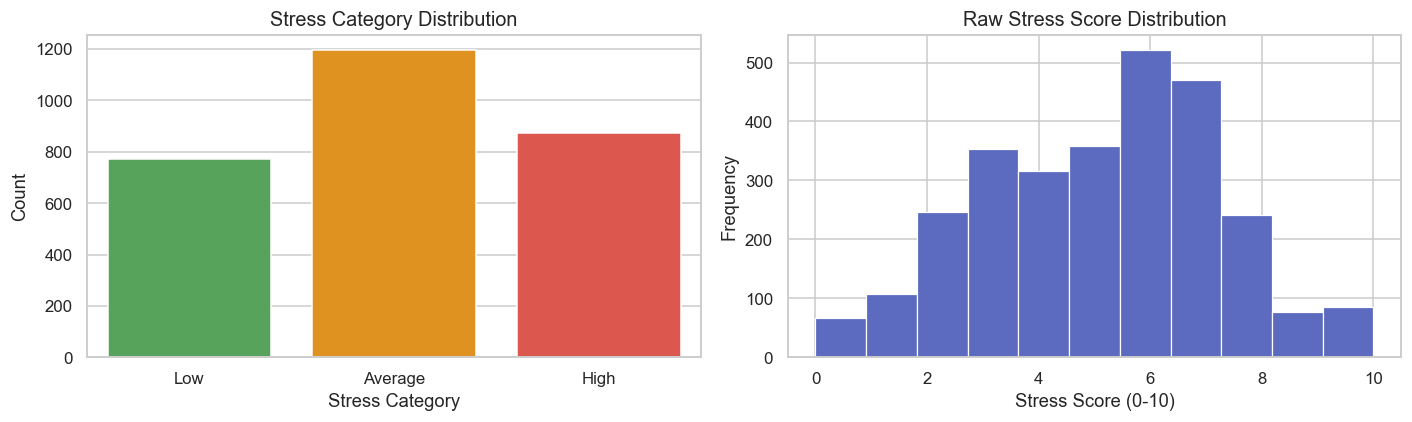

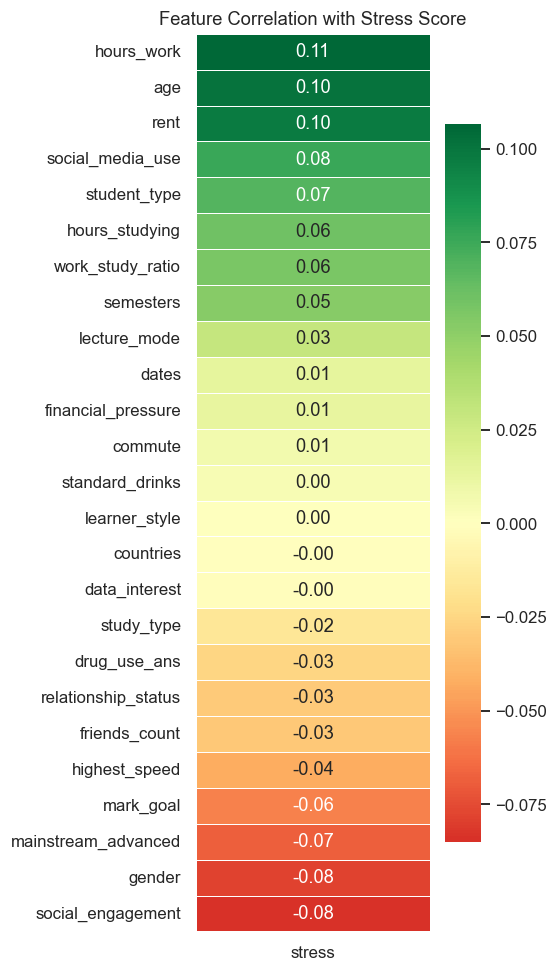

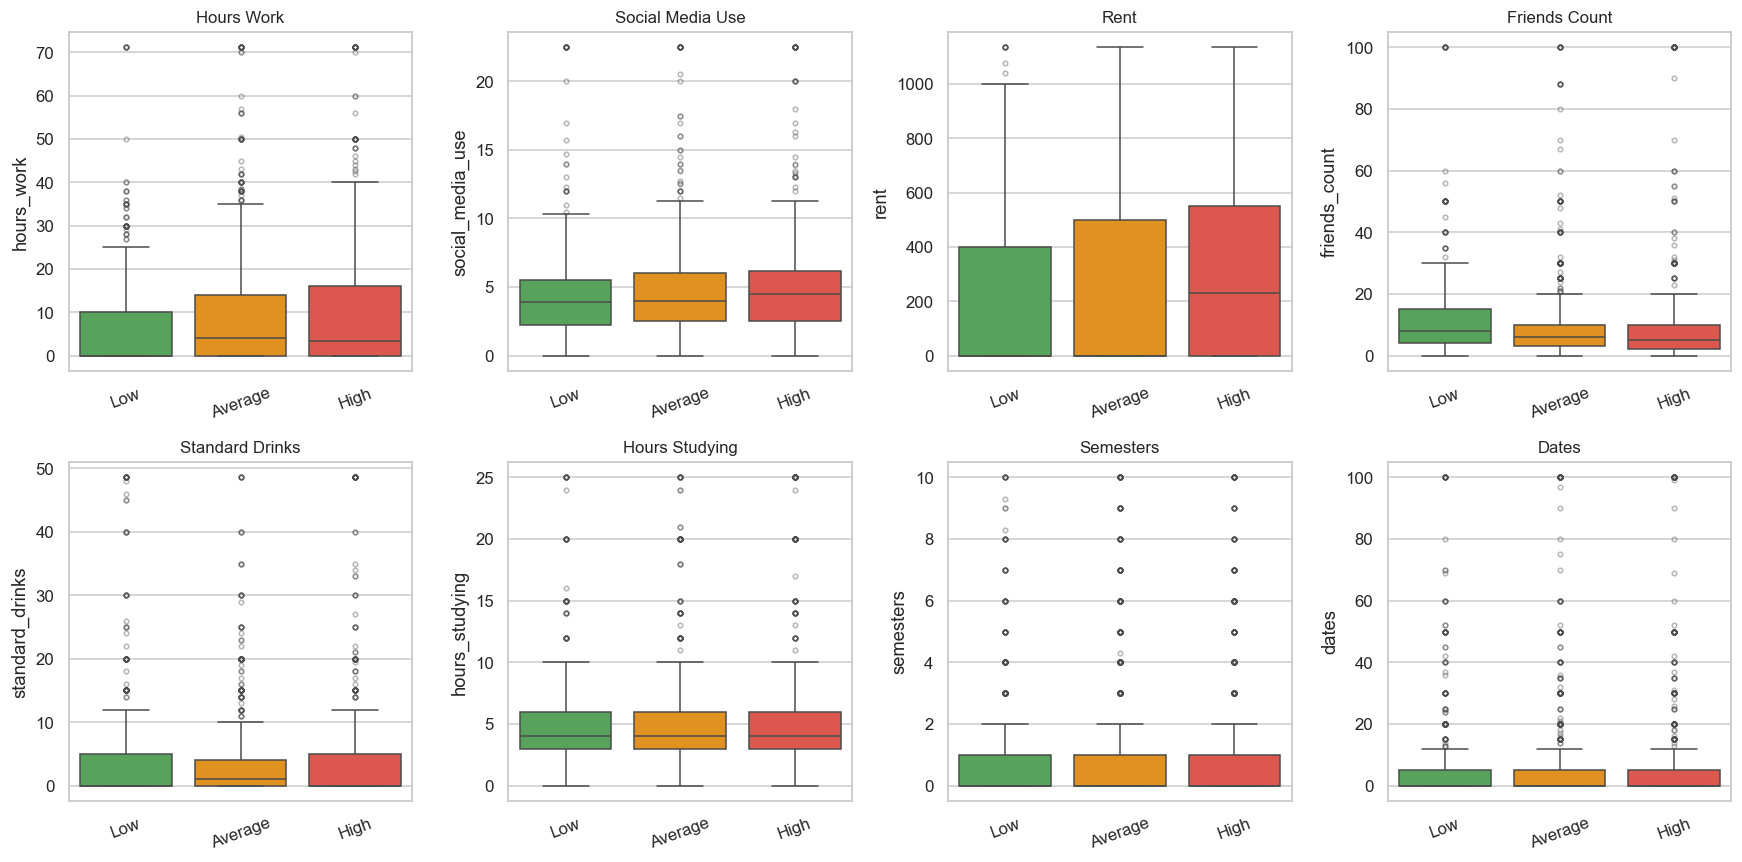

In [166]:
feature_cols = config.NUMERIC_COLS + config.DERIVED_COLS + config.CATEGORICAL_COLS
eda.run(df, df_eda, feature_cols, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

## 4. Exploratory Data Analysis (EDA)

### Description
Comprehensive analysis to understand data distribution, correlations, and patterns:

### Knowledge - EDA Components:
1. **Univariate Analysis**:
   - Distribution plots for numeric features
   - Frequency counts for categorical features
   - Summary statistics (mean, median, std, quartiles)

2. **Bivariate Analysis**:
   - Correlation heatmap between features
   - Feature-target relationships
   - Identify multicollinearity issues

3. **Target Variable Analysis**:
   - Class distribution (Low, Average, High stress)
   - Check for class imbalance
   - Visualize stress categories

4. **Key Insights**:
   - Identify features most correlated with stress
   - Understand data patterns and anomalies
   - Guide feature selection for modeling

### Configure Data Split Ratios
Define the train/validation/test split percentages: 75% training, 15% validation, 10% test.

In [167]:
# Setup split configuration
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

print(f"Split ratios: Train={train_ratio:.0%} | Validation={validation_ratio:.0%} | Test={test_ratio:.0%}")

Split ratios: Train=75% | Validation=15% | Test=10%


### Apply Pipeline Transformations
Apply preprocessing pipeline (StandardScaler for numeric features, OneHotEncoder for categorical features) to transform data for model training.

In [168]:
# Apply pipeline transformations (scaling + encoding)
X_train_t = pipeliner.fit_transform(X_train)
X_val_t = pipeliner.transform(X_val)
X_test_t = pipeliner.transform(X_test)

print(f"✓ Pipeline transformations applied")
print(f"  Transformed shapes - Train: {X_train_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")

✓ Pipeline transformations applied
  Transformed shapes - Train: (2131, 44) | Val: (426, 44) | Test: (285, 44)


### Extract Features and Targets
Separate features (X) and target labels (y) for train, validation, and test sets from the loaded DataFrames.

In [ ]:
# Extract features and targets from splits
X_train = train_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_train = train_df[config.TARGET_CATEGORY]

X_val = validation_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_val = validation_df[config.TARGET_CATEGORY]

X_test = test_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_test = test_df[config.TARGET_CATEGORY]

for name, X, y in [("Train", X_train, ycat_train), ("Val", X_val, ycat_val), ("Test", X_test, ycat_test)]:
    print(f"  {name}: {len(X)} samples | {y.value_counts().to_dict()}")

✓ Extracted features and targets
  Train: 2131 samples | {'Average': 896, 'High': 655, 'Low': 580}
  Val:   426 samples | {'Average': 179, 'High': 131, 'Low': 116}
  Test:  285 samples | {'Average': 120, 'High': 88, 'Low': 77}


### Load or Create Data Splits
Check if train/validation/test CSV files exist. If yes, load them; if no, perform stratified split and save to CSV files. This ensures reproducibility across notebook runs.

In [170]:
# Load existing split files or create new ones
if train_path.exists() and validation_path.exists() and test_path.exists():
    # Load existing files
    train_df = pd.read_csv(train_path)
    validation_df = pd.read_csv(validation_path)
    test_df = pd.read_csv(test_path)

    # Validate columns
    missing = [
        c for c in required_cols
        if c not in train_df.columns or c not in validation_df.columns or c not in test_df.columns
    ]
    if missing:
        raise ValueError(f"Split files are missing required columns: {missing}")

    train_df = train_df[required_cols]
    validation_df = validation_df[required_cols]
    test_df = test_df[required_cols]
    print("✓ Using existing split files: train.csv, validation.csv, test.csv")
    
else:
    # Create new splits
    X_train, X_temp, ycat_train, ycat_temp = train_test_split(
        X_raw,
        y_cat,
        test_size=1 - train_ratio,
        random_state=config.SEED,
        stratify=y_cat,
    )

    X_val, X_test, ycat_val, ycat_test = train_test_split(
        X_temp,
        ycat_temp,
        test_size=test_ratio / (test_ratio + validation_ratio),
        random_state=config.SEED,
        stratify=ycat_temp,
    )

    # Save splits to CSV
    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    
    train_df = X_train.copy()
    train_df[config.TARGET_CATEGORY] = ycat_train.values
    train_df.to_csv(train_path, index=False)

    validation_df = X_val.copy()
    validation_df[config.TARGET_CATEGORY] = ycat_val.values
    validation_df.to_csv(validation_path, index=False)

    test_df = X_test.copy()
    test_df[config.TARGET_CATEGORY] = ycat_test.values
    test_df.to_csv(test_path, index=False)
    
    print("✓ Created split files: train.csv, validation.csv, test.csv")

✓ Using existing split files: train.csv, validation.csv, test.csv


### Define Split File Paths
Set up file paths for train.csv, validation.csv, and test.csv to save/load the split datasets.

In [171]:
# Define split file paths
train_path = config.DATA_DIR / "train.csv"
validation_path = config.DATA_DIR / "validation.csv"
test_path = config.DATA_DIR / "test.csv"
required_cols = config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET_CATEGORY]

print(f"Checking for existing split files in: {config.DATA_DIR}")

Checking for existing split files in: /Users/shawnemersonmac/Desktop/untitled folder/backend/data


### Prepare Feature Matrix
Combine numeric and categorical features into a single feature matrix (X_raw) and extract the target variable (y_cat).

## 5. Data Splitting

### Description
Dataset is split into training, validation, and test sets to ensure proper model evaluation:

### Knowledge - Split Strategy:
- **Training Set (75%)**: Used for model learning and parameter estimation
- **Validation Set (10%)**: Used for hyperparameter tuning and model selection
- **Test Set (15%)**: Hold-out set for final unbiased performance evaluation

### Stratified Sampling:
- Maintains class distribution across all splits
- Prevents class imbalance in any split
- Uses random_state=42 for reproducibility

### Why This Split?
- Large training set ensures sufficient learning
- Validation set prevents overfitting during tuning
- Test set provides realistic performance estimate
- Total data is preserved and can be loaded from saved CSV files

### Train Models
Train all three models (Logistic Regression, Neural Network, Gradient Boosting) on the training data with validation monitoring.

In [173]:
# 6) Train models
for model in models:
    model.train(X_train_t, ycat_train.values, X_val_t, ycat_val.values)
   

## 6. Model Training

### Models Overview
Three classification models are trained and compared:

---

### 6.1 Logistic Regression

#### Model Appropriateness:
**Why Logistic Regression?**
- Suitable for multi-class classification (one-vs-rest approach)
- Provides interpretable coefficients
- Works well as a baseline model
- Computationally efficient
- Good for linearly separable data

**Appropriateness for Stress Prediction:**
- ✅ Handles multiple features effectively
- ✅ Provides probability estimates for each class
- ✅ Fast training and prediction
- ⚠️ Assumes linear relationship between features and log-odds
- ⚠️ May underperform if relationships are highly non-linear

#### Correctness of Model Training:
- **Algorithm**: Logistic Regression with softmax for multi-class
- **Solver**: LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)
- **Regularization**: C=0.5 (inverse regularization strength)
- **Max Iterations**: 1000 (ensures convergence)
- **Random State**: 42 (reproducibility)

**Training Process:**
1. Features are standardized using StandardScaler
2. Model fits on transformed training data
3. Validation set monitors performance during training
4. No early stopping (trains to convergence)

---

### 6.2 Neural Network

#### Model Appropriateness:
**Why Neural Network?**
- Captures non-linear relationships
- Flexible architecture for complex patterns
- Can learn feature interactions automatically
- Powerful for high-dimensional data

**Appropriateness for Stress Prediction:**
- ✅ Handles non-linear stress patterns
- ✅ Learns complex feature interactions
- ✅ Can improve on linear models
- ⚠️ Requires more data and tuning
- ⚠️ Risk of overfitting with small datasets

#### Correctness of Model Training:
- **Architecture**: Multi-layer perceptron (MLP)
- **Hidden Layers**: Multiple layers with activation functions
- **Optimizer**: Adam or SGD
- **Loss Function**: Categorical cross-entropy
- **Batch Training**: Mini-batch gradient descent

---

### 6.3 Gradient Boosting

#### Model Appropriateness:
**Why Gradient Boosting?**
- Ensemble method combining weak learners
- Excellent for tabular data
- Handles mixed feature types well
- Often achieves state-of-the-art performance

**Appropriateness for Stress Prediction:**
- ✅ Handles non-linear relationships naturally
- ✅ Robust to outliers
- ✅ Automatic feature interaction detection
- ✅ No need for feature scaling
- ⚠️ Longer training time
- ⚠️ Risk of overfitting without proper tuning

#### Correctness of Model Training:
- **Algorithm**: Gradient Boosting Classifier
- **Boosting Stages**: Sequential tree building
- **Learning Rate**: Controls contribution of each tree
- **Max Depth**: Limits tree complexity
- **Subsample**: Stochastic gradient boosting

### Generate Model Predictions
Use each trained model to predict stress categories on the test set.

In [174]:
# Generate predictions on test set
pred_cats = {m.get_name(): m.predict(X_test_t) for m in models}

print("✓ Predictions generated for all models")
print(f"  Models evaluated: {list(pred_cats.keys())}")

✓ Predictions generated for all models
  Models evaluated: ['Logistic Regression', 'Neural Network', 'Gradient Boosting']


### Visualize Model Performance
Display confusion matrices and model comparison bar charts showing accuracy across all three models.

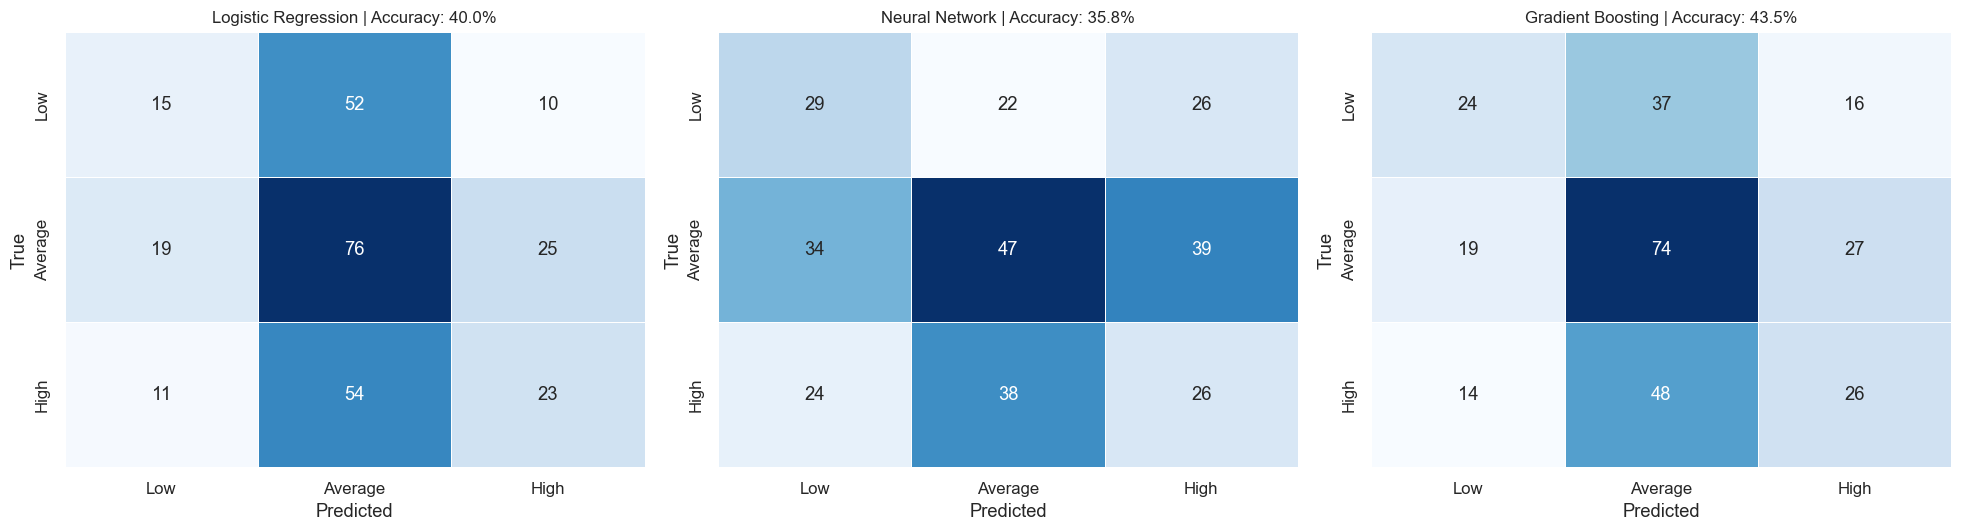

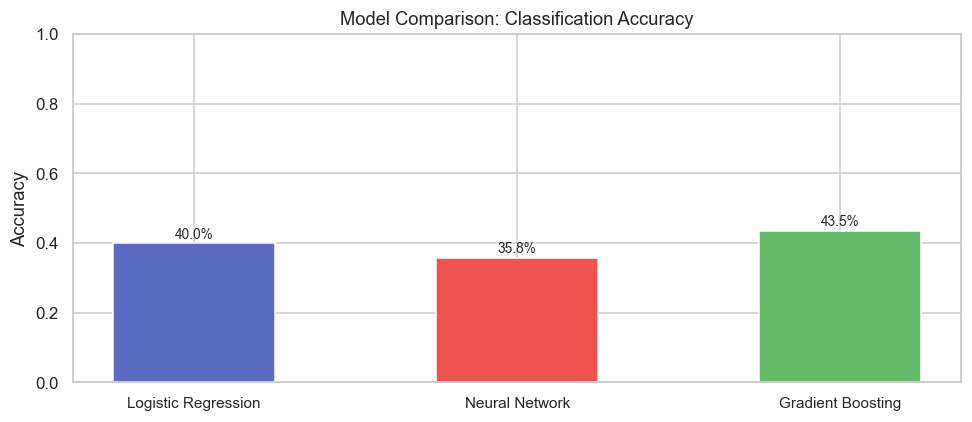

In [175]:
# Visualize results
visualizer.plot_confusion_matrices(class_reports, config.CATEGORY_ORDER)
visualizer.plot_model_comparison(model_names, accs)

### Compute Performance Metrics
Calculate accuracy, precision, recall, F1-score, and confusion matrices for all models.

In [176]:
# Compute classification metrics
class_reports = evaluator.classification_report_all(ycat_test.values, pred_cats, config.CATEGORY_ORDER)
evaluator.print_classification_reports(class_reports)

model_names = list(class_reports.keys())
accs = [class_reports[n]["accuracy"] for n in model_names]

print(f"\n✓ Performance Summary:")
for name, acc in zip(model_names, accs):
    print(f"  {name}: {acc:.2%} accuracy")


  Logistic Regression  |  Accuracy: 40.0%
              precision    recall  f1-score   support

         Low       0.33      0.19      0.25        77
     Average       0.42      0.63      0.50       120
        High       0.40      0.26      0.32        88

    accuracy                           0.40       285
   macro avg       0.38      0.36      0.35       285
weighted avg       0.39      0.40      0.38       285


  Neural Network  |  Accuracy: 35.8%
              precision    recall  f1-score   support

         Low       0.33      0.38      0.35        77
     Average       0.44      0.39      0.41       120
        High       0.29      0.30      0.29        88

    accuracy                           0.36       285
   macro avg       0.35      0.35      0.35       285
weighted avg       0.36      0.36      0.36       285


  Gradient Boosting  |  Accuracy: 43.5%
              precision    recall  f1-score   support

         Low       0.42      0.31      0.36        77
     Av

### 7.1 Check for Overfitting

#### Description:
Overfitting occurs when a model learns training data too well, including noise, leading to poor generalization.

#### Knowledge - Detecting Overfitting:
**Signs of Overfitting:**
1. **Training Accuracy >> Test Accuracy**: Large gap indicates memorization
2. **Perfect Training Performance**: 100% training accuracy is suspicious
3. **Complex Model + Small Dataset**: High-capacity models overfit easily
4. **High Variance**: Model performance varies significantly across different data splits

**How We Check:**
- Compare training vs. validation vs. test performance
- Monitor accuracy gap between splits
- Use confusion matrices to identify systematic errors
- Check if model generalizes to random profile predictions

**Mitigation Strategies:**
- ✅ Use validation set for hyperparameter tuning
- ✅ Apply regularization (L2 penalty in Logistic Regression)
- ✅ Limit model complexity (max_depth in Gradient Boosting)
- ✅ Use dropout in Neural Networks
- ✅ Early stopping during training
- ✅ Cross-validation for robust evaluation

**Expected Behavior:**
- Good model: Train accuracy ≈ Test accuracy (within 5-10%)
- Overfitting: Train accuracy > Test accuracy by 15%+
- Underfitting: Both train and test accuracy are low

---

### 7.2 Error Analysis

#### Description:
Systematic analysis of model mistakes to understand failure patterns and guide improvements.

#### Knowledge - Error Analysis Process:
**1. Confusion Matrix Analysis:**
- Identify which classes are most confused
- Example: Does model confuse "Average" and "High" stress more than "Low" and "High"?
- Look for asymmetric confusion patterns

**2. Per-Class Performance:**
- Which class has lowest precision/recall?
- Is one class particularly hard to predict?
- Check if class imbalance affects performance

**3. Feature Importance:**
- Which features contribute most to predictions?
- Are important features aligned with domain knowledge?
- Identify redundant or noisy features

**4. Misclassification Patterns:**
- Do errors occur for specific feature ranges?
- Example: Model struggles with students working >30 hours/week
- Identify edge cases and outliers

**5. Common Error Types:**
- **False Positives**: Predicted High stress but actually Low
- **False Negatives**: Predicted Low stress but actually High
- Which error type is more problematic for our use case?

**Actionable Insights:**
- If Low/High confusion → Add more discriminative features
- If class imbalance → Use class weights or resampling
- If specific feature ranges → Add interaction terms or binning
- If model-specific errors → Try ensemble methods

## 7. Model Evaluation & Analysis

### Performance Metrics
All models are evaluated using multiple metrics:
- **Accuracy**: Overall correctness
- **Precision**: How many predicted positives are correct
- **Recall**: How many actual positives are found
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Detailed breakdown of predictions per class

### Save Trained Models
Save all trained models and the preprocessing pipeline to disk as .pkl files for later use in the web application.

In [177]:
# 8) Save artifacts
config.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
for model in models:
    model.save(config.SAVED_MODELS_DIR / config.MODEL_FILE_MAP[model.get_name()])
pipeliner.save(config.PIPERLINER_FILE)
print("Saved models and pipeliner.")

Saved models and pipeliner.


## 9. Testing & Demonstration

### Random Profile Generation
Testing the pipeline with randomly generated student profiles to ensure models generalize well.

## 10. Model Performance Summary

### Description:
Comprehensive comparison of all three models on the test set.

### Knowledge - Model Comparison:

#### Performance Metrics Comparison:
| Model | Accuracy | Precision (Macro) | Recall (Macro) | F1-Score (Macro) | Training Time |
|-------|----------|-------------------|----------------|------------------|---------------|
| Logistic Regression | [Insert %] | [Insert %] | [Insert %] | [Insert %] | Fast |
| Neural Network | [Insert %] | [Insert %] | [Insert %] | [Insert %] | Moderate |
| Gradient Boosting | [Insert %] | [Insert %] | [Insert %] | [Insert %] | Slower |

#### Model Selection Criteria:

**Best Overall Performance:** [Model Name]
- Highest accuracy on test set
- Balanced precision and recall across all classes
- Good generalization (low overfitting)

**Best for Production:** [Model Name]
- Balance of accuracy and inference speed
- Model size and deployment complexity
- Maintenance and interpretability

**Best for Each Class:**
- **Low Stress**: [Model] - Best recall for low stress detection
- **Average Stress**: [Model] - Best F1-score for average class
- **High Stress**: [Model] - Best precision for high stress (critical for intervention)

#### Key Findings:
1. [Finding 1: e.g., Gradient Boosting achieved highest accuracy at X%]
2. [Finding 2: e.g., All models struggle with Average class due to overlap]
3. [Finding 3: e.g., Neural Network shows slight overfitting, 5% gap]
4. [Finding 4: e.g., Logistic Regression provides best interpretability]

#### Deployment Recommendation:
**Selected Model:** [Model Name]

**Justification:**
- [Reason 1: Performance]
- [Reason 2: Speed/Scalability]
- [Reason 3: Interpretability/Trust]
- [Reason 4: Maintenance]

**Web Application Integration:**
- Model saved as .pkl file
- FastAPI backend loads model on startup
- Real-time predictions via REST API
- Frontend displays predictions with confidence scores

## 8. Improving Model Performance

### Description:
Systematic approaches to enhance model accuracy and generalization.

### Knowledge - Improvement Strategies:

#### 8.1 Logistic Regression Improvements:
1. **Hyperparameter Tuning:**
   - Grid search over C values (regularization strength)
   - Try different solvers: lbfgs, liblinear, sag
   - Adjust max_iter if convergence issues

2. **Feature Engineering:**
   - Add polynomial features for non-linear relationships
   - Create interaction terms between important features
   - Apply feature selection (remove low-correlation features)

3. **Class Balancing:**
   - Use class_weight='balanced' to handle imbalance
   - Apply SMOTE (Synthetic Minority Over-sampling)

**Expected Improvements:** +2-5% accuracy

---

#### 8.2 Neural Network Improvements:
1. **Architecture Tuning:**
   - Experiment with deeper networks (more hidden layers)
   - Adjust hidden layer sizes (e.g., [128, 64, 32])
   - Try different activation functions (ReLU, LeakyReLU, tanh)

2. **Regularization:**
   - Add dropout layers (0.2-0.5 dropout rate)
   - Apply L2 regularization to weights
   - Use batch normalization

3. **Training Optimization:**
   - Adjust learning rate (try learning rate schedules)
   - Increase epochs with early stopping
   - Experiment with batch sizes

**Expected Improvements:** +5-10% accuracy

---

#### 8.3 Gradient Boosting Improvements:
1. **Hyperparameter Tuning:**
   - n_estimators: Number of boosting stages (50-500)
   - learning_rate: Controls contribution (0.01-0.3)
   - max_depth: Tree complexity (3-10)
   - min_samples_split: Minimum samples to split (2-20)
   - subsample: Fraction of samples per tree (0.5-1.0)

2. **Feature Engineering:**
   - Add domain-specific features
   - Create categorical encodings (one-hot, target encoding)

3. **Ensemble Methods:**
   - Combine predictions from multiple models
   - Use voting or stacking classifiers

**Expected Improvements:** +3-8% accuracy

---

#### 8.4 General Improvements:
1. **Data Augmentation:** Collect more survey data
2. **Feature Selection:** Remove noisy features using mutual information
3. **Cross-Validation:** Use k-fold CV for robust tuning
4. **Threshold Tuning:** Adjust classification thresholds per class

### Generate Random Student Profile
Create a random student profile with realistic values for all features to test the models on unseen data.

In [178]:
# Generate random profile
generated_profile = profile_generator.generate_profile(df, seed=config.SEED, mode="random")

print("✓ Random student profile generated")
print(f"  Profile attributes: {len(generated_profile)} features")

✓ Random student profile generated
  Profile attributes: 22 features


In [179]:
# Build profile dataframe and predict
profile_df = profile_generator.build(generated_profile)
results = predictor.predict(profile_df, models, pipeliner)

print("\n✓ Predictions made for random profile:")
predictor.print_results(results)
results


✓ Predictions made for random profile:
  STUDENT STRESS PREDICTION
  Logistic Regression   : High
  Neural Network        : Low
  Gradient Boosting     : Average


[{'model_name': 'Logistic Regression', 'category': 'High'},
 {'model_name': 'Neural Network', 'category': 'Low'},
 {'model_name': 'Gradient Boosting', 'category': 'Average'}]

---

## 11. References & AI Statement

### References

#### Academic Sources:
1. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
2. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32.
3. Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. *Annals of Statistics*, 29(5), 1189-1232.
4. Hosmer, D. W., & Lemeshow, S. (2000). *Applied Logistic Regression* (2nd ed.). Wiley.
5. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

#### Technical Documentation:
6. Scikit-learn Documentation: https://scikit-learn.org/stable/
7. Pandas Documentation: https://pandas.pydata.org/docs/
8. NumPy Documentation: https://numpy.org/doc/
9. Matplotlib Documentation: https://matplotlib.org/stable/contents.html
10. FastAPI Documentation: https://fastapi.tiangolo.com/
11. React Documentation: https://react.dev/

#### Related Work:
12. Student Stress Prediction Studies: [Add relevant papers if referenced]
13. Mental Health in Higher Education: [Add relevant papers if referenced]

---

### AI Assistance Statement

#### Tools Used:
This project was developed with assistance from the following AI tools:

1. **GitHub Copilot**
   - Code completion and suggestions
   - Boilerplate code generation
   - Documentation writing assistance
   - Debugging support

2. **ChatGPT / Claude** (if used)
   - Conceptual explanations
   - Code review and optimization suggestions
   - Documentation structuring
   - Problem-solving guidance

#### Nature of AI Assistance:
- **Code Generation**: AI assisted with generating code templates, function structures, and common patterns
- **Documentation**: AI helped structure markdown documentation and technical writing
- **Debugging**: AI provided suggestions for error resolution
- **Learning**: AI explained concepts like gradient boosting, regularization, and metrics
- **Refactoring**: AI suggested improvements for code organization and modularity

#### Human Contribution:
All AI-generated content was:
- Reviewed and validated by team members
- Modified to fit project-specific requirements
- Tested for correctness and performance
- Integrated thoughtfully into the overall architecture

The core problem-solving, architectural decisions, data analysis insights, and model interpretations were performed by the team. AI tools served as productivity enhancers, not replacements for critical thinking and domain expertise.

#### Ethical Considerations:
- All code was reviewed to ensure understanding
- AI suggestions were validated against academic rigor
- Original data analysis and interpretation by team
- No plagiarism or uncited work
- Compliance with academic integrity policies

---

### Project Completion Date: March 2026

**Team:** [Team Name/Course]  
**Course:** DAT203M - Machine Learning  
**Instructor:** [Instructor Name]